# AI Fitness Tracker — Statistical Analysis

This notebook presents the statistical analyses performed on simulated fitness data for 500 users across 22,226 daily activity logs.

We apply three SciPy statistical methods:
- **ANOVA** — test whether calories burned differ significantly across workout types
- **Linear Regression** — model a user's step trend and predict future activity
- **Paired T-Test** — determine whether users rate high-intensity workouts differently than low-intensity ones

The dataset was generated using the `generate_users.py` script and includes realistic variation in fitness levels, equipment, injuries, and daily activity patterns.

## Setup

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from stats_analysis import anova_calories_by_workout, regression_steps_trend, ttest_workout_intensity_ratings

sns.set_theme(style='darkgrid')

df_users = pd.read_csv('../data/processed/users.csv')
df_logs  = pd.read_csv('../data/processed/logs.csv', parse_dates=['date'])

print(f'Users: {df_users.shape}, Logs: {df_logs.shape}')

Users: (500, 12), Logs: (22226, 7)


---
## 1. ANOVA — Do calories burned differ significantly across workout types?

### Background
A one-way ANOVA (Analysis of Variance) tests whether the means of three or more independent groups are significantly different from one another. Here, our groups are the different workout types and our measure is calories burned per session.

### Hypotheses
- **H₀ (Null):** The mean calories burned is equal across all workout types
- **H₁ (Alternative):** At least one workout type produces a significantly different calorie burn

### Significance threshold
We use the standard threshold of **α = 0.05**. If p < 0.05 we reject the null hypothesis.

In [2]:
anova = anova_calories_by_workout(df_logs)
for k, v in anova.items():
    print(f'{k}: {v}')

f_statistic: 847.8245
p_value: 0.0
significant: True
conclusion: Calorie burn differs significantly across workout types.


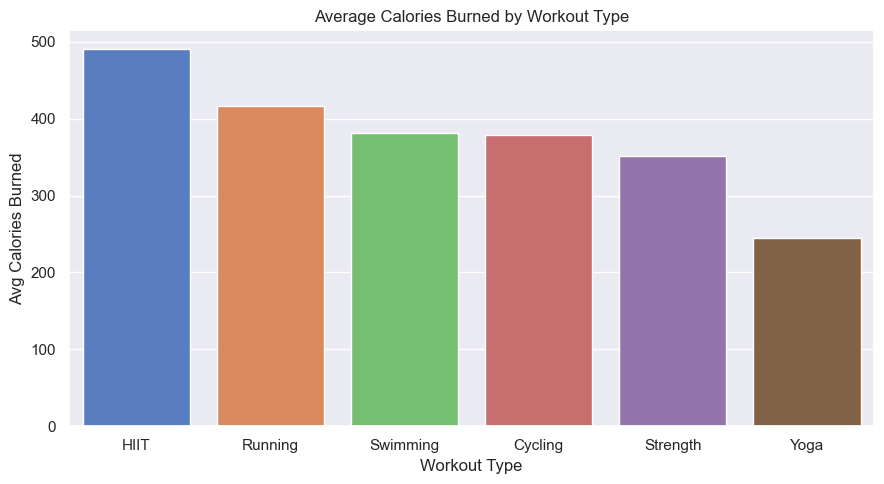

In [3]:
active = df_logs[df_logs['workout_type'] != 'Rest']
avg_calories = active.groupby('workout_type')['calories_burned'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=avg_calories, x='workout_type', y='calories_burned', hue='workout_type', palette='muted', legend=False, ax=ax)
ax.set_title('Average Calories Burned by Workout Type')
ax.set_xlabel('Workout Type')
ax.set_ylabel('Avg Calories Burned')
plt.tight_layout()
plt.show()

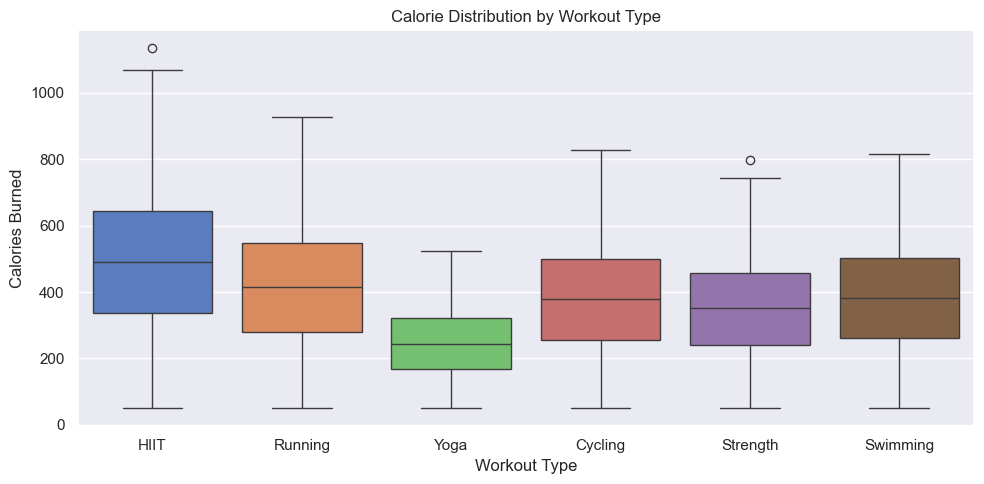

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=active, x='workout_type', y='calories_burned', hue='workout_type', palette='muted', legend=False, ax=ax)
ax.set_title('Calorie Distribution by Workout Type')
ax.set_xlabel('Workout Type')
ax.set_ylabel('Calories Burned')
plt.tight_layout()
plt.show()

### Results & Interpretation

| Metric | Value |
|--------|-------|
| F-statistic | 847.82 |
| p-value | ~0.0 |
| Significant | Yes |

**We reject the null hypothesis.** The F-statistic of 847.82 is extremely large, and the p-value is effectively zero — far below our threshold of 0.05. This tells us that calorie burn differs significantly across workout types.

The bar chart confirms this visually: HIIT produces the highest average calorie burn (~490 kcal), while Yoga produces the lowest (~245 kcal). The box plot shows that while there is spread within each group, the group means are clearly separated.

**Note:** The strength of this result is partly by design — we applied calorie multipliers per workout type during data generation to simulate realistic physiological differences. In real-world data the effect would likely still be significant but with greater overlap between groups.

---
## 2. Linear Regression — Can we predict a user's future step count?

### Background
Linear regression models the relationship between two continuous variables by fitting a straight line through the data. Here we treat time (day number) as the independent variable and daily steps as the dependent variable. The resulting trend line can be extended to predict future step counts.

### Hypotheses
- **H₀ (Null):** There is no linear relationship between time and step count (slope = 0)
- **H₁ (Alternative):** A significant linear trend exists in the user's step count over time

We demonstrate this on **User u_0001** — a 19-year-old advanced user with a strength goal.

In [5]:
user_logs = df_logs[df_logs['user_id'] == 'u_0001'].copy()
regression = regression_steps_trend(user_logs)
for k, v in regression.items():
    print(f'{k}: {v}')

slope: 57.78
r_squared: 0.0213
p_value: 0.418212
trend: improving
predicted_steps: [9175, 9233, 9291, 9349, 9406, 9464, 9522]


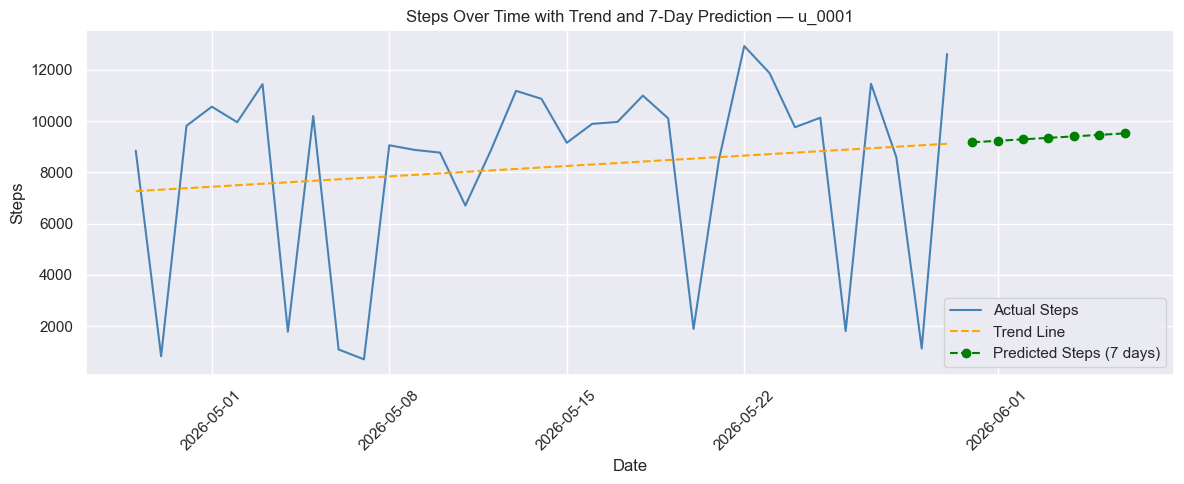

In [6]:
user_logs = user_logs.sort_values('date').copy()
user_logs['day_num'] = (user_logs['date'] - user_logs['date'].min()).dt.days

slope, intercept, r_value, p_value, std_err = stats.linregress(user_logs['day_num'], user_logs['steps'])
trend_line = slope * user_logs['day_num'] + intercept

last_day = user_logs['day_num'].max()
future_days = np.array([last_day + i for i in range(1, 8)])
future_steps = slope * future_days + intercept
future_dates = pd.date_range(user_logs['date'].max() + pd.Timedelta(days=1), periods=7)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(user_logs['date'], user_logs['steps'], label='Actual Steps', color='steelblue')
ax.plot(user_logs['date'], trend_line, label='Trend Line', color='orange', linestyle='--')
ax.plot(future_dates, future_steps, label='Predicted Steps (7 days)', color='green', linestyle='--', marker='o')
ax.set_title('Steps Over Time with Trend and 7-Day Prediction — u_0001')
ax.set_xlabel('Date')
ax.set_ylabel('Steps')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Results & Interpretation

| Metric | Value |
|--------|-------|
| Slope | 57.78 steps/day |
| R² | 0.0213 |
| p-value | 0.418 |
| Trend | Improving |
| Predicted steps (next 7 days) | 9,175 → 9,522 |

**We fail to reject the null hypothesis.** The p-value of 0.418 is well above our threshold of 0.05, meaning the upward trend is not statistically significant.

The slope of 57.78 suggests the user's steps are increasing by roughly 58 per day on average. However, the R² of 0.021 tells us the trend line explains only **2.1% of the variance** in daily steps — the remaining 97.9% is noise. The line chart confirms this: daily steps are highly erratic with large swings between active days and rest days.

**This is a realistic and honest result.** Individual daily step counts are naturally volatile. A meaningful trend would typically only emerge over a longer time window (3-6 months rather than 30-60 days). The predicted values of 9,175–9,522 steps are plausible given the user's advanced fitness level, but should be interpreted with caution given the weak model fit.

**For the future ML model:** this is exactly why a single linear regression is insufficient for fitness prediction. A model that accounts for workout type, rest days, and weekly patterns would produce far more reliable predictions.

---
## 3. Paired T-Test — Do users rate high-intensity workouts differently than low-intensity?

### Background
A paired t-test compares the means of two related groups to determine whether their difference is statistically significant. We pair equal-sized samples from high-intensity (HIIT, Running) and low-intensity (Yoga, Swimming) workout ratings.

### Hypotheses
- **H₀ (Null):** The mean workout rating is the same for high and low intensity workouts
- **H₁ (Alternative):** Users rate high and low intensity workouts significantly differently

This is relevant for the recommendation engine — if intensity level significantly affects satisfaction, it should be a weighted factor in workout suggestions.

In [7]:
ttest = ttest_workout_intensity_ratings(df_logs)
for k, v in ttest.items():
    print(f'{k}: {v}')

t_statistic: 0.8787
p_value: 0.379579
significant: False
high_intensity_avg: 3.02
low_intensity_avg: 3.0
conclusion: No significant difference in ratings between high and low intensity workouts.


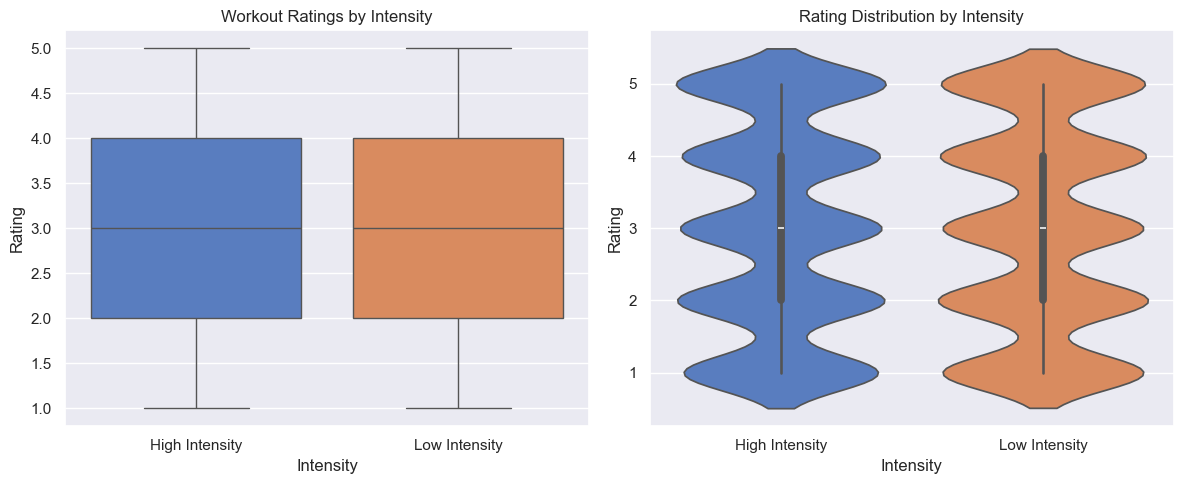

In [8]:
high_intensity = ['HIIT', 'Running']
low_intensity  = ['Yoga', 'Swimming']

intensity_df = df_logs[df_logs['workout_type'].isin(high_intensity + low_intensity)].copy()
intensity_df['intensity'] = intensity_df['workout_type'].apply(
    lambda x: 'High Intensity' if x in high_intensity else 'Low Intensity'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=intensity_df, x='intensity', y='workout_rating', hue='intensity', palette='muted', legend=False, ax=axes[0])
axes[0].set_title('Workout Ratings by Intensity')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Rating')

sns.violinplot(data=intensity_df, x='intensity', y='workout_rating', hue='intensity', palette='muted', legend=False, ax=axes[1])
axes[1].set_title('Rating Distribution by Intensity')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

### Results & Interpretation

| Metric | Value |
|--------|-------|
| T-statistic | 0.8787 |
| p-value | 0.379 |
| Significant | No |
| High intensity avg rating | 3.02 / 5 |
| Low intensity avg rating | 3.00 / 5 |

**We fail to reject the null hypothesis.** The p-value of 0.379 is well above 0.05. The average ratings are nearly identical (3.02 vs 3.00), and the t-statistic of 0.88 is far too small to indicate a meaningful difference.

The violin plots confirm this — both distributions are almost perfectly uniform across all rating values (1–5), which is expected since workout ratings were generated randomly in our simulation without any intensity bias.

**What this means for the recommendation engine:** In this simulated dataset, workout intensity is not a predictor of user satisfaction. However, in real-world data we would expect to see a meaningful signal here — users with certain goals (e.g. weight loss) may consistently rate high-intensity workouts higher, while users in rehabilitation may rate them lower. This test would be far more informative with real user feedback data collected through the thumbs up/down system built into the dashboard.

---
## Summary

| Analysis | Method | Result | Significant |
|----------|--------|--------|-------------|
| Calories by workout type | One-way ANOVA | F=847.82, p≈0.0 | ✅ Yes |
| Steps trend over time | Linear Regression | R²=0.021, p=0.418 | ❌ No |
| Ratings by intensity | Paired T-Test | t=0.88, p=0.379 | ❌ No |

### Key Takeaways

1. **Workout type is a strong predictor of calorie burn.** The ANOVA result is unambiguous — HIIT and Running produce significantly higher calorie expenditure than Yoga and Strength training. This is a meaningful input for the workout recommendation engine.

2. **Short-term step trends are noisy and unreliable.** The regression model explains less than 3% of variance in daily steps. A longer data window and more features (e.g. workout type, rest day patterns) would be needed to build a useful prediction model — which is exactly what the future ML layer of this project will address.

3. **Simulated ratings lack the signal needed for intensity-based recommendations.** The t-test result is expected given randomly generated ratings. In production, the user feedback loop (thumbs up/down on exercises) will generate real preference data that makes this analysis meaningful.

### Limitations
- All data is simulated. Calorie multipliers were manually set, which inflates the ANOVA result.
- 30–60 days of data per user is insufficient for reliable trend modelling.
- Workout ratings were generated uniformly at random, removing any real preference signal.

These limitations are intentional — the primary purpose of this project is to build the data pipeline and analytical foundation for a future machine learning model that will operate on real user data.